In [203]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [204]:
AVAdata = pd.read_csv("ValidZipCodeData.csv")
AVAdata.head()

,Account Number,Levy Year,Land Value,Building Value,Total Value,Zip Code
0,50299400,2025,3031482,1364125,4395607,22314
1,50299400,2024,3031482,1364125,4395607,22314
2,50299400,2023,3031482,1364125,4395607,22314
3,50299400,2022,3031482,1364125,4395607,22314
4,50299400,2021,3031482,1364125,4395607,22314


In [213]:
ZipCodeColors = ["brown", "purple", "blue", "green", "yellow", "orange", "red", "pink"]

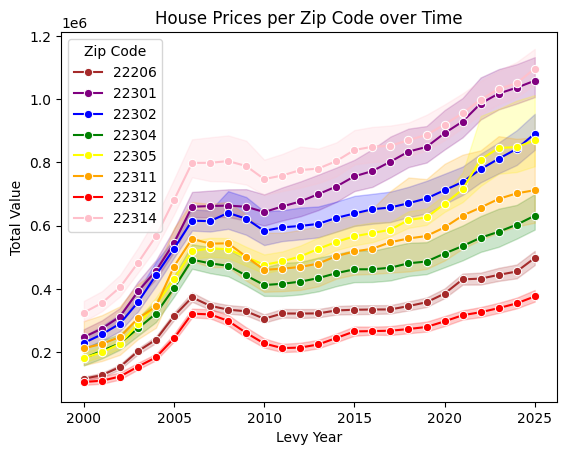

In [214]:
sns.lineplot(data=AVAdata, x="Levy Year", y="Total Value", hue="Zip Code", marker="o", palette=ZipCodeColors)
plt.title("House Prices per Zip Code over Time")
plt.show()

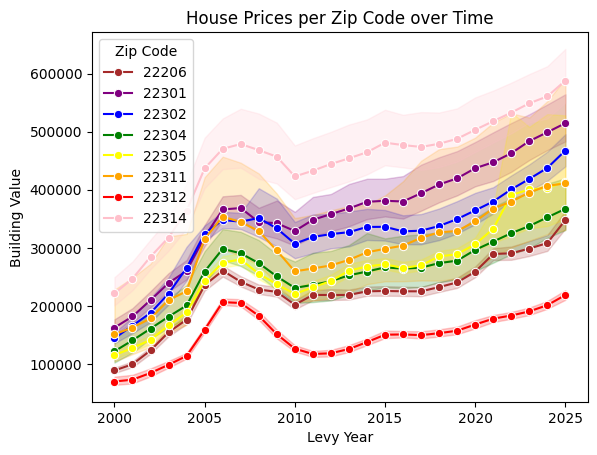

In [217]:
sns.lineplot(data=AVAdata, x="Levy Year", y="Building Value", hue="Zip Code", marker="o", palette=ZipCodeColors)
plt.title("House Prices per Zip Code over Time")
plt.show()

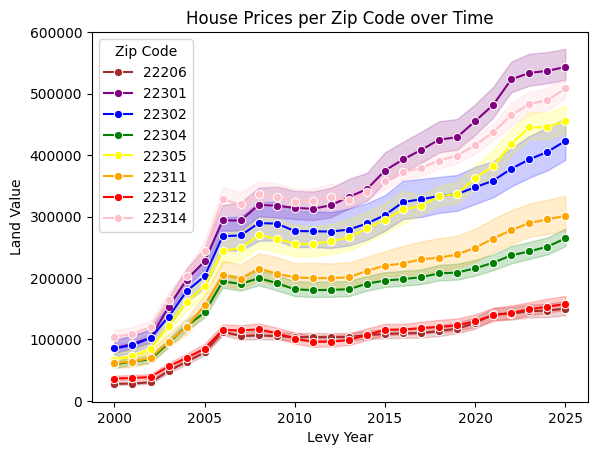

In [219]:
sns.lineplot(data=AVAdata, x="Levy Year", y="Land Value", hue="Zip Code", marker="o", palette=ZipCodeColors)
plt.title("House Prices per Zip Code over Time")
plt.show()

We need to put some of the zip codes into other zip codes, because there are only 8 that make up the map display of Alexandria Zip Codes. Some are just smaller zip code markers essentially. 

In [195]:
AVAdata.dtypes

Account Number    int64
Levy Year         int64
Land Value        int64
Building Value    int64
Total Value       int64
Zip Code          int64
dtype: object

In [221]:
AccountData = AVAdata.groupby("Account Number").agg({"Land Value": "mean", "Building Value": "mean", "Total Value": "mean", "Zip Code": "first", "Levy Year":list}).reset_index()
AccountData

,Account Number,Land Value,Building Value,Total Value,Zip Code,Levy Year
0,10006030,0.000000e+00,0.000000e+00,0.000000e+00,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201..."
1,10009500,2.042008e+06,0.000000e+00,2.042008e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201..."
2,10040600,1.367554e+06,3.048785e+06,4.416338e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201..."
3,10042500,3.024962e+05,0.000000e+00,3.024962e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201..."
4,10043000,2.756538e+05,0.000000e+00,2.756538e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201..."
...,...,...,...,...,...,...
32672,60049800,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025]
32673,60049810,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025]
32674,60049820,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025]
32675,60049830,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025]


In [223]:
AvaBuildLand = pd.read_csv("Ava_Streets_Table.csv").rename(columns={"A_Account_Num": "Account Number"})
AvaBuildLand.head()

,Unnamed: 0,A_Properties,A_Current_Owner,Account Number,A_SQFT
0,1,3000 S 28TH ST,\r\r\n\t\t\t\t\t\tCITY OF ALEXANDRIA\t\t,50299410,1
1,2,3102 S 28TH ST,\r\r\n\t\t\t\t\t\tALEXANDRIA REDEVELOPMENTHOUS...,50299400,1
2,3,"3200 S 28TH ST, UNIT 101",\r\r\n\t\t\t\t\t\tBEGUM SAIRAKHALEK MOHAMMAD A...,50466800,1090
3,4,"3200 S 28TH ST, UNIT 102",\r\r\n\t\t\t\t\t\tCHESLEY JOHN W III AND JUDIT...,50466810,1280
4,5,"3200 S 28TH ST, UNIT 201",\r\r\n\t\t\t\t\t\tSILVA HUGO TRNEGRONI ANDREA ...,50466820,700


In [225]:
AvaBuildLand = AvaBuildLand.drop(columns={"Unnamed: 0"})
AvaBuildLand.head()

,A_Properties,A_Current_Owner,Account Number,A_SQFT
0,3000 S 28TH ST,\r\r\n\t\t\t\t\t\tCITY OF ALEXANDRIA\t\t,50299410,1
1,3102 S 28TH ST,\r\r\n\t\t\t\t\t\tALEXANDRIA REDEVELOPMENTHOUS...,50299400,1
2,"3200 S 28TH ST, UNIT 101",\r\r\n\t\t\t\t\t\tBEGUM SAIRAKHALEK MOHAMMAD A...,50466800,1090
3,"3200 S 28TH ST, UNIT 102",\r\r\n\t\t\t\t\t\tCHESLEY JOHN W III AND JUDIT...,50466810,1280
4,"3200 S 28TH ST, UNIT 201",\r\r\n\t\t\t\t\t\tSILVA HUGO TRNEGRONI ANDREA ...,50466820,700


In [227]:
FullAccountData = pd.merge(AccountData, AvaBuildLand, how="left", on="Account Number")
FullAccountData.head()

,Account Number,Land Value,Building Value,Total Value,Zip Code,Levy Year,A_Properties,A_Current_Owner,A_SQFT
0,10006030,0.000000e+00,0.000000e+00,0.000000e+00,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",309 HOLLAND LA,\r\r\n\t\t\t\t\t\tROYALTON CONDOMINIUM\t\t,0
1,10009500,2.042008e+06,0.000000e+00,2.042008e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",500 HOLLAND LA,\r\r\n\t\t\t\t\t\tBAPTIST CEMETARY ASSOC OF AL...,1
2,10040600,1.367554e+06,3.048785e+06,4.416338e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",205 DAINGERFIELD RD,\r\r\n\t\t\t\t\t\tNATIONAL SOCIETY OF BLACK EN...,17460
3,10042500,3.024962e+05,0.000000e+00,3.024962e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",1601A DUKE ST,\r\r\n\t\t\t\t\t\tVINCI EDUCATION CORPORATION\t\t,0
4,10043000,2.756538e+05,0.000000e+00,2.756538e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",1603 DUKE ST,\r\r\n\t\t\t\t\t\tVINCI EDUCATION CORPORATION\t\t,0


In [229]:
FullAccountData["A_Current_Owner"] = FullAccountData["A_Current_Owner"].str.replace(r"[\r\n\t]+", "", regex=True)
FullAccountData

,Account Number,Land Value,Building Value,Total Value,Zip Code,Levy Year,A_Properties,A_Current_Owner,A_SQFT
0,10006030,0.000000e+00,0.000000e+00,0.000000e+00,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",309 HOLLAND LA,ROYALTON CONDOMINIUM,0
1,10009500,2.042008e+06,0.000000e+00,2.042008e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",500 HOLLAND LA,BAPTIST CEMETARY ASSOC OF ALEXANDRIA,1
2,10040600,1.367554e+06,3.048785e+06,4.416338e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",205 DAINGERFIELD RD,NATIONAL SOCIETY OF BLACK ENGINEERS,17460
3,10042500,3.024962e+05,0.000000e+00,3.024962e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",1601A DUKE ST,VINCI EDUCATION CORPORATION,0
4,10043000,2.756538e+05,0.000000e+00,2.756538e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",1603 DUKE ST,VINCI EDUCATION CORPORATION,0
...,...,...,...,...,...,...,...,...,...
32714,60049800,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025],4922 CUMBERLAND ST,ELAMIN SARAH OR WAILE,1950
32715,60049810,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025],4920 CUMBERLAND ST,XIAO GUOXIAN OR CHANG QING,1950
32716,60049820,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025],4918 CUMBERLAND ST,PETERSON ERIK OR GEORGE NIDHI,1950
32717,60049830,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025],4916 CUMBERLAND ST,THORNTON JAYSON MICHAELOR THORNTON MARQUITA MI...,1950


In [231]:
FullAccountData["A_Properties"] = FullAccountData["A_Properties"].str.replace(r"([0-9]+).", "", regex=True)
FullAccountData

,Account Number,Land Value,Building Value,Total Value,Zip Code,Levy Year,A_Properties,A_Current_Owner,A_SQFT
0,10006030,0.000000e+00,0.000000e+00,0.000000e+00,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",HOLLAND LA,ROYALTON CONDOMINIUM,0
1,10009500,2.042008e+06,0.000000e+00,2.042008e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",HOLLAND LA,BAPTIST CEMETARY ASSOC OF ALEXANDRIA,1
2,10040600,1.367554e+06,3.048785e+06,4.416338e+06,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",DAINGERFIELD RD,NATIONAL SOCIETY OF BLACK ENGINEERS,17460
3,10042500,3.024962e+05,0.000000e+00,3.024962e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",DUKE ST,VINCI EDUCATION CORPORATION,0
4,10043000,2.756538e+05,0.000000e+00,2.756538e+05,22314,"[2025, 2024, 2023, 2022, 2021, 2020, 2019, 201...",DUKE ST,VINCI EDUCATION CORPORATION,0
...,...,...,...,...,...,...,...,...,...
32714,60049800,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025],CUMBERLAND ST,ELAMIN SARAH OR WAILE,1950
32715,60049810,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025],CUMBERLAND ST,XIAO GUOXIAN OR CHANG QING,1950
32716,60049820,2.420000e+05,5.298550e+05,7.718550e+05,22304,[2025],CUMBERLAND ST,PETERSON ERIK OR GEORGE NIDHI,1950
32717,60049830,4.400000e+05,5.298550e+05,9.698550e+05,22304,[2025],CUMBERLAND ST,THORNTON JAYSON MICHAELOR THORNTON MARQUITA MI...,1950


The Long Short-Term Memory network, or LSTM network, is a recurrent neural network trained using Backpropagation Through Time that overcomes the vanishing gradient problem.

In [233]:
OwnerDataTable = FullAccountData.groupby('A_Current_Owner').agg({'Land Value':'sum', 'Building Value':'sum', 'Total Value':'sum','A_SQFT':'sum'})
OwnerDataTable.head()

,Land Value,Building Value,Total Value,A_SQFT
A_Current_Owner,,,,
,9.000856e+06,1.071781e+07,1.971866e+07,54267
ALLEN RUSSELL OR FRIEDMAN KYLE REBECCA,2.120592e+05,1.563995e+05,3.684588e+05,860
CORONA ANNA MARIEROMERO ANDREW,2.238037e+05,2.487135e+05,4.725171e+05,1102
IGYARTO KEITH EDWARD AND LORI PEARL TRS,5.756726e+05,6.359418e+05,1.211614e+06,3060
JASTRAB DAVID OR STERLING AMANDA,3.379823e+05,3.317128e+05,6.696951e+05,1904
